# 실습 15: 언제부터 그랬는지 보기
- 상황: 이상한 줄은 찾았는데 그게 언제 나온 건지 모른다
- 목표: 시각을 되살려 흐름으로 감시하고, 조기 경보 목록으로 마감한다

## Step 0. 앞 실습까지 재현하기

In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv('../../day02/lab06_clean-dataset/results/secom_clean.csv')

sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

X = df[sensor_cols]

탐지기 = IsolationForest(contamination=0.05, random_state=42)
지목 = 탐지기.fit_predict(X)

df["불량여부"] = (df['result'] == '불량').astype(int)
df["이상탐지"] = (지목 == -1)

print('전체 행 수:', df.shape[0])
print('이상탐지 건수:', int(df['이상탐지'].sum()))
print('그중 불량:', int((df['이상탐지'] & (df['불량여부'] == 1)).sum()))

전체 행 수: 1567
이상탐지 건수: 79
그중 불량: 12


## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 흐름으로 보는 말

| 수업에서 쓰는 말 | 정식 이름 | 뜻 |
|---|---|---|
| 시계열 | time series | 시간 순서가 있는 기록. 앞뒤가 이어져 있어서 순서를 바꾸면 뜻이 달라진다 |
| 이동평균 | 이동평균 (moving average) | 최근 몇 개의 평균. 들쭉날쭉한 걸 눌러서 흐름만 남긴다 |
| 관리도 | 관리도 (control chart) | 평소 범위를 선으로 그려두고 넘는 순간을 잡는 그림 |
| 관리 한계선 | 관리상한 UCL / 관리하한 LCL | 그 선. 흔히 평균에서 표준편차의 세 배만큼 위아래로 긋는다 |
| 이탈 | 관리 이탈 (out of control) | 관리 한계선을 넘은 것 |
| 관리도로 공정을 지켜보는 일 | 통계적 공정관리 (SPC) | 현장에서 백 년 가까이 써온 방법. 면접에서 이 이름으로 묻는다 |

## Step 2. 떨어져 나간 시각 다시 붙이기

In [2]:
import pandas as pd

# ① 파일을 불러오는 것 - 첫날부터 계속 쓴 것
원본 = pd.read_csv("../../data/04_secom.csv")

# ② 글자로 된 시각을 날짜로 바꿔주는 것
# ③ 표기가 섞여 있어도 알아서 읽으라는 뜻. 안 넣으면 오류가 난다
df["측정시각"] = pd.to_datetime(원본["measured_at"], format='mixed')

# 붙이기 전에 확인 - 두 파일의 행 순서가 같아야 붙일 수 있다
# ④ 전부 참일 때만 참이 되는 것
print("정제본 행 수:", len(df), "/ 원본 행 수:", len(원본))
print("답이 전부 같은가:", (df["result"].values == 원본["result"].values).all())

# ⑤ 그 열 기준으로 줄을 세우는 것
# ⑥ 옛 번호를 버리라는 뜻
df = df.sort_values("측정시각").reset_index(drop=True)

print("기간:", df["측정시각"].min(), "~", df["측정시각"].max())

정제본 행 수: 1567 / 원본 행 수: 1567
답이 전부 같은가: True
기간: 2008-01-08 02:02:00 ~ 2008-12-10 18:47:00


TRUE라는 뜻은 원본행과 정제본 행이 같다.

### 문법 노트 - 시각 붙이고 줄 세우기

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ① | `read_csv` | 파일을 불러온다 | 첫날부터 계속 쓴 것 |
| ② | `to_datetime` | 글자로 된 시각을 날짜로 바꾼다 | 정제할 때 한 번 나왔다 |
| ③ | `format="mixed"` | 표기가 섞여 있어도 알아서 읽으라는 뜻 | 새로 배움 · 안 넣으면 오류 |
| ④ | `.all()` | 전부 참일 때만 참 | 새로 배움 |
| ⑤ | `sort_values` | 그 열 기준으로 줄을 세운다 | 새로 배움 |
| ⑥ | `drop` | 번호를 다시 매기고 옛 번호는 버린다 | 새로 배움 |

## Step 4. 월별로 보면

In [3]:
# 측정시각에서 연-월만 뽑아 월별로 묶는다
df["측정월"] = df["측정시각"].dt.to_period("M")

월별 = df.groupby("측정월").agg(
    전체건수=("불량여부", "size"),
    불량건수=("불량여부", "sum"),
)
월별["불량률(%)"] = round(월별["불량건수"] / 월별["전체건수"] * 100, 2)

print(월별)

최고 = 월별["불량률(%)"].idxmax()
최저 = 월별["불량률(%)"].idxmin()

print()
print(f"불량률이 가장 높은 달: {최고} ({월별.loc[최고, '불량률(%)']}%) / "
      f"가장 낮은 달: {최저} ({월별.loc[최저, '불량률(%)']}%)")

         전체건수  불량건수  불량률(%)
측정월                        
2008-01    51     3    5.88
2008-02    98     5    5.10
2008-03    50     1    2.00
2008-04    49     3    6.12
2008-05    62     7   11.29
2008-06    67     6    8.96
2008-07   114    16   14.04
2008-08   471    38    8.07
2008-09   413    17    4.12
2008-10   123     6    4.88
2008-11    35     2    5.71
2008-12    34     0    0.00



불량률이 가장 높은 달: 2008-07 (14.04%) / 가장 낮은 달: 2008-12 (0.0%)


## Step 5. 흐름 보고 관리선 긋기

In [4]:
# 볼 센서 하나를 고른다
센서 = "sensor_039"

# ⑦ 창문을 미끄러뜨리며 묶어주는 것
# ⑧ 몇 개씩 묶을지 정하는 자리
# ⑨ 묶은 것들의 평균을 내는 것
df["이동평균"] = df[센서].rolling(window=20).mean()

# 평소 범위를 정한다. 첫날에 한 그 방법이다
# ⑩ 값들이 평균에서 얼마나 벌어져 있는지 재는 것
평균 = df[센서].mean()
표준편차 = df[센서].std()

# ⑪ 평균에서 표준편차의 몇 배만큼 그을지
상한 = 평균 + 3 * 표준편차
하한 = 평균 - 3 * 표준편차

print(f"평균 {평균:.2f} / 표준편차 {표준편차:.2f}")
print(f"관리 상한 {상한:.2f} / 관리 하한 {하한:.2f}")

# ⑫ 위로 넘었거나 아래로 넘었거나 - 한쪽만 참이어도 참인 기호
df["이탈"] = (df[센서] > 상한) | (df[센서] < 하한)

# 불량 표시를 df 안에서 다시 만든다
df["불량여부"] = (df["result"] == "불량").astype(int)

print("이탈:", df["이탈"].sum(), "건 / 그중 불량", (df["이탈"] & (df["불량여부"] == 1)).sum(), "건")

평균 86.84 / 표준편차 0.45
관리 상한 88.18 / 관리 하한 85.50
이탈: 71 건 / 그중 불량 15 건


### 문법 노트 - 흐름과 관리선

선을 넘었는지 볼 때 두 조건을 묶는다.

    위로 넘었거나 아래로 넘었거나  ->  |

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ⑦ | `rolling` | 창문을 미끄러뜨리며 묶는다 | 새로 배움 |
| ⑧ | `window` | 몇 개씩 묶을지 정하는 자리 | 새로 배움 |
| ⑨ | `.mean()` | 묶은 것들의 평균 | 첫날부터 쓴 것 |
| ⑩ | `.std()` | 표준편차 - 평균에서 얼마나 벌어져 있나 | 첫날 관리선·지난주 흔들림에서 썼다 |
| ⑪ | `3` | 표준편차의 세 배로 선을 긋는다 | 첫날에 정한 그 배수 |
| ⑫ | `\|` | 한쪽이라도 참이면 참 | 앞 실습에서 배웠다 |

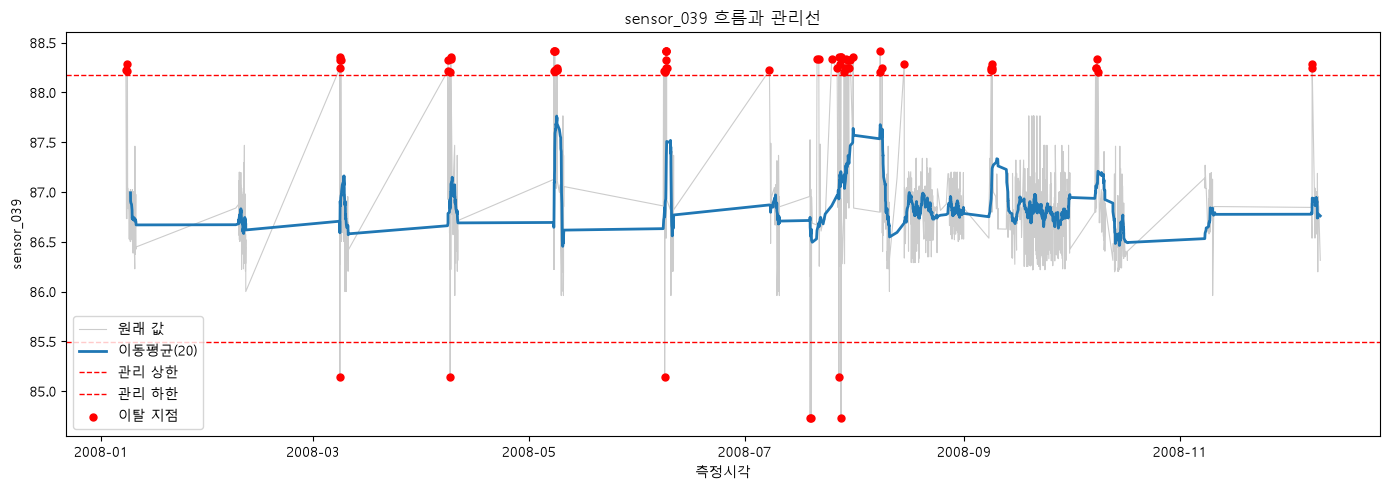

저장 완료: C:\Users\13sx0\Desktop\SECOM-PROJECT\day05\lab15_timeseries\results\sensor_trend.png


In [5]:
import matplotlib.pyplot as plt
import os

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs('results', exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 5))

# 원래 값은 옅게, 이동평균은 진하게
ax.plot(df["측정시각"], df[센서], color='gray', alpha=0.4, linewidth=0.8, label='원래 값')
ax.plot(df["측정시각"], df["이동평균"], color='tab:blue', linewidth=2, label='이동평균(20)')

# 관리 상한·하한을 가로선으로
ax.axhline(상한, color='red', linestyle='--', linewidth=1, label='관리 상한')
ax.axhline(하한, color='red', linestyle='--', linewidth=1, label='관리 하한')

# 선을 넘은 지점만 눈에 띄게 표시
이탈행 = df[df["이탈"]]
ax.scatter(이탈행["측정시각"], 이탈행[센서], color='red', s=25, zorder=5, label='이탈 지점')

ax.set_xlabel('측정시각')
ax.set_ylabel(센서)
ax.set_title(f'{센서} 흐름과 관리선')
ax.legend()
plt.tight_layout()

plt.savefig('results/sensor_trend.png', dpi=150)
plt.show()

print('저장 완료:', os.path.abspath('results/sensor_trend.png'))

Step 6: 조기 경보 목록으로 마감하기 ⭐

In [6]:
import numpy as np

# df["이상탐지"]와 df["이탈"] 두 열만으로 걸린 근거를 적는다
df["근거"] = np.where(
    df["이상탐지"] & df["이탈"], "둘 다",
    np.where(df["이상탐지"], "이상탐지",
             np.where(df["이탈"], "관리선", ""))
)

# 둘 중 하나라도 걸린 줄만 남기고, "둘 다"가 맨 위로 오게 우선순위를 매겨 정렬한다
조기경보 = df[df["이상탐지"] | df["이탈"]].copy()
조기경보["우선순위"] = np.where(조기경보["근거"] == "둘 다", 0, 1)
조기경보 = 조기경보.sort_values("우선순위").drop(columns="우선순위")

print(조기경보[["측정시각", "근거", "불량여부"]])

# 1. 둘 다 걸린 것
둘다건수 = int((df["이상탐지"] & df["이탈"]).sum())
둘다불량 = int((df["이상탐지"] & df["이탈"] & (df["불량여부"] == 1)).sum())

# 2. 둘 중 하나라도 걸린 것
하나건수 = int((df["이상탐지"] | df["이탈"]).sum())
하나불량 = int(((df["이상탐지"] | df["이탈"]) & (df["불량여부"] == 1)).sum())

# 3. 이 목록(둘 중 하나)으로 못 잡은 불량
전체불량 = int(df["불량여부"].sum())
못잡은불량 = 전체불량 - 하나불량

# 4. 전체 불량률
전체불량률 = round(df["불량여부"].mean() * 100, 2)

집계표 = pd.DataFrame([
    {'항목': '둘 다 걸린 것', '건수': 둘다건수, '그중 불량': 둘다불량,
     '지목 중 진짜(%)': round(둘다불량 / 둘다건수 * 100, 1) if 둘다건수 else 0.0},
    {'항목': '둘 중 하나라도', '건수': 하나건수, '그중 불량': 하나불량,
     '지목 중 진짜(%)': round(하나불량 / 하나건수 * 100, 1) if 하나건수 else 0.0},
    {'항목': '이 목록으로 못 잡은 불량', '건수': 못잡은불량, '그중 불량': '-', '지목 중 진짜(%)': '-'},
    {'항목': '전체 불량률', '건수': '-', '그중 불량': '-', '지목 중 진짜(%)': 전체불량률},
]).set_index('항목')

print()
print(집계표)

                    측정시각    근거  불량여부
5    2008-01-08 12:29:00   둘 다     0
149  2008-03-08 13:09:00   둘 다     0
152  2008-03-08 15:03:00   둘 다     0
201  2008-04-08 03:49:00   둘 다     0
254  2008-05-08 03:36:00   둘 다     0
...                  ...   ...   ...
1533 2008-12-08 04:23:00  이상탐지     0
1525 2008-11-10 07:39:00  이상탐지     0
1534 2008-12-08 06:16:00  이상탐지     0
1536 2008-12-08 11:29:00   관리선     0
1540 2008-12-09 06:38:00  이상탐지     0

[119 rows x 3 columns]

                 건수 그중 불량 지목 중 진짜(%)
항목                                  
둘 다 걸린 것         31     8       25.8
둘 중 하나라도        119    19       16.0
이 목록으로 못 잡은 불량   85     -          -
전체 불량률            -     -       6.64


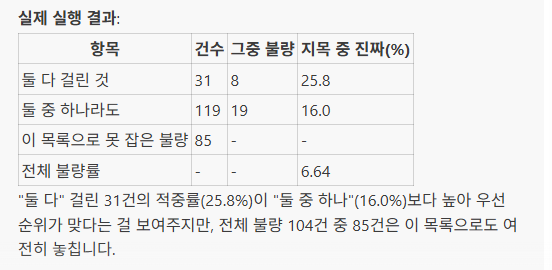

## Step 6. 조기 경보 리포트

| 걸린 근거 | 건수 | 그중 불량 | 지목 중 진짜 |
|---|---|---|---|
| 둘 다 | [31] | [8] | [25.8%] |
| 둘 중 하나라도 | [119] | [19] | [16%] |
| (견줄 값) 전체 불량률 | 1567 | [104] | [6.64%] |

- 먼저 열어볼 것 : [둘 다 걸린 27건. 전체 불량률의 네 배 반이라 여기부터 본다]
- 무엇을 근거로 : [이상탐지 두 방법이 같이 짚었고, 관리선도 넘었다]
- 놓친 것 : [불량 104건 중 85건은 이 목록에 없다]
- 아직 못 미더운 점 : [관리선은 센서 하나만 봤다. 나머지 마흔아홉 개는 안 봤다]
- 다음에 해볼 것 : [센서를 더 골라 관리선을 긋고 겹치는지 본다]

---
## 직접 해보기 (도전) - 센서를 더 보면 달라지나

- 상황: 관리선을 센서 하나에만 그었다. 더 그으면 어떻게 될까
- 할 일: 센서를 여러 개 골라 관리선을 긋고, 몇 개나 넘었는지로 순위를 매긴다
- 결과물: 다섯 줄짜리 표 1개 + 한 줄 메모

In [7]:
# 센서마다 평균±3표준편차로 관리선을 긋고, 이탈 건수를 세어본다
이탈건수_센서별 = {}
for s in sensor_cols:
    평균_s = df[s].mean()
    표준편차_s = df[s].std()
    이탈_s = (df[s] > 평균_s + 3 * 표준편차_s) | (df[s] < 평균_s - 3 * 표준편차_s)
    이탈건수_센서별[s] = int(이탈_s.sum())

# 이탈 건수가 20~100건 사이인 센서만 후보로 남기고, 그중 다섯 개를 고른다
후보센서 = [s for s in sensor_cols if 20 <= 이탈건수_센서별[s] <= 100]
선택센서 = 후보센서[:5]

print("조건(이탈 20~100건)을 만족하는 센서:", len(후보센서), "개")
print("고른 다섯 센서:", 선택센서)
print("각 센서 이탈 건수:", {s: 이탈건수_센서별[s] for s in 선택센서})

조건(이탈 20~100건)을 만족하는 센서: 18 개
고른 다섯 센서: ['sensor_511', 'sensor_432', 'sensor_431', 'sensor_022', 'sensor_211']
각 센서 이탈 건수: {'sensor_511': 32, 'sensor_432': 32, 'sensor_431': 32, 'sensor_022': 24, 'sensor_211': 28}


In [8]:
# 고른 다섯 센서마다 이탈 여부를 구해서, 줄마다 몇 개 센서에서 넘었는지 센다
경보수 = pd.Series(0, index=df.index)
for s in 선택센서:
    평균_s = df[s].mean()
    표준편차_s = df[s].std()
    이탈_s = (df[s] > 평균_s + 3 * 표준편차_s) | (df[s] < 평균_s - 3 * 표준편차_s)
    경보수 += 이탈_s.astype(int)

df["경보수"] = 경보수

print(df["경보수"].value_counts().sort_index())

경보수
0    1478
1      57
2       8
3      21
4       3
Name: count, dtype: int64


In [9]:
# 경보수를 0, 1, 2, 3 이상 네 구간으로 나눠 건수·불량·적중률을 본다
결과_경보수 = []
for 구간이름, 조건 in [
    ('0', df["경보수"] == 0),
    ('1', df["경보수"] == 1),
    ('2', df["경보수"] == 2),
    ('3 이상', df["경보수"] >= 3),
]:
    건수 = int(조건.sum())
    그중불량 = int((조건 & (df["불량여부"] == 1)).sum())
    결과_경보수.append({
        '경보수': 구간이름,
        '건수': 건수,
        '그중 불량': 그중불량,
        '지목 중 진짜(%)': round(그중불량 / 건수 * 100, 1) if 건수 > 0 else 0.0,
    })

경보수표 = pd.DataFrame(결과_경보수).set_index('경보수')
경보수표

,건수,그중 불량,지목 중 진짜(%)
경보수,,,
0,1478,86,5.8
1,57,11,19.3
2,8,1,12.5
3 이상,24,6,25.0


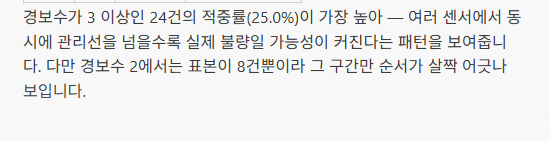

### 몇 개의 센서에서 넘었나

| 넘은 센서 개수 | 그런 줄 | 그중 불량 | 지목 중 진짜 |
|---|---|---|---|
| 0개 | [1478] | [86] | [5.82%] |
| 1개 | [57] | [11] | [19.30%] |
| 2개 | [8] | [1] | [12.50%] |
| 3개 이상 | [24] | [6] | [25.00%] |

- 알게 된 것 : [하나도 안 걸린 줄은 5.82%로 전체와 비슷하고, 세 개 이상 걸린 줄은 25.00%로 네 배다. 2개 줄은 8건뿐이라 비율이 튀다]

In [10]:
# 이동평균 자체의 평균·표준편차로 관리선을 다시 긋는다 (2 표준편차 기준)
이동평균_평균 = df["이동평균"].mean()
이동평균_표준편차 = df["이동평균"].std()
이동평균_상한 = 이동평균_평균 + 2 * 이동평균_표준편차
이동평균_하한 = 이동평균_평균 - 2 * 이동평균_표준편차

print(f"이동평균의 평균 {이동평균_평균:.3f} / 표준편차 {이동평균_표준편차:.3f}")
print(f"이동평균 관리 상한 {이동평균_상한:.3f} / 관리 하한 {이동평균_하한:.3f}")

이동평균_이탈 = (df["이동평균"] > 이동평균_상한) | (df["이동평균"] < 이동평균_하한)

# 연속된 이탈 구간을 하나로 묶는다
블록번호 = (이동평균_이탈 != 이동평균_이탈.shift()).cumsum()

구간목록 = []
for 번호, 블록df in df[이동평균_이탈].groupby(블록번호[이동평균_이탈]):
    전체건수 = len(블록df)
    불량건수 = int(블록df["불량여부"].sum())
    구간목록.append({
        '시작': 블록df["측정시각"].min(),
        '끝': 블록df["측정시각"].max(),
        '전체건수': 전체건수,
        '불량건수': 불량건수,
        '불량률(%)': round(불량건수 / 전체건수 * 100, 2) if 전체건수 > 0 else 0.0,
    })

구간표 = pd.DataFrame(구간목록)

print()
print("넘은 구간 수:", len(구간표))
print(구간표)

이동평균의 평균 86.835 / 표준편차 0.193
이동평균 관리 상한 87.221 / 관리 하한 86.449

넘은 구간 수: 5
                   시작                   끝  전체건수  불량건수  불량률(%)
0 2008-05-08 07:12:00 2008-05-10 04:48:00    21     2    9.52
1 2008-06-08 20:17:00 2008-06-10 04:26:00    15     2   13.33
2 2008-07-29 15:49:00 2008-07-29 15:49:00     1     1  100.00
3 2008-07-29 21:07:00 2008-08-09 04:21:00    27     5   18.52
4 2008-09-08 23:34:00 2008-09-13 00:25:00    13     2   15.38


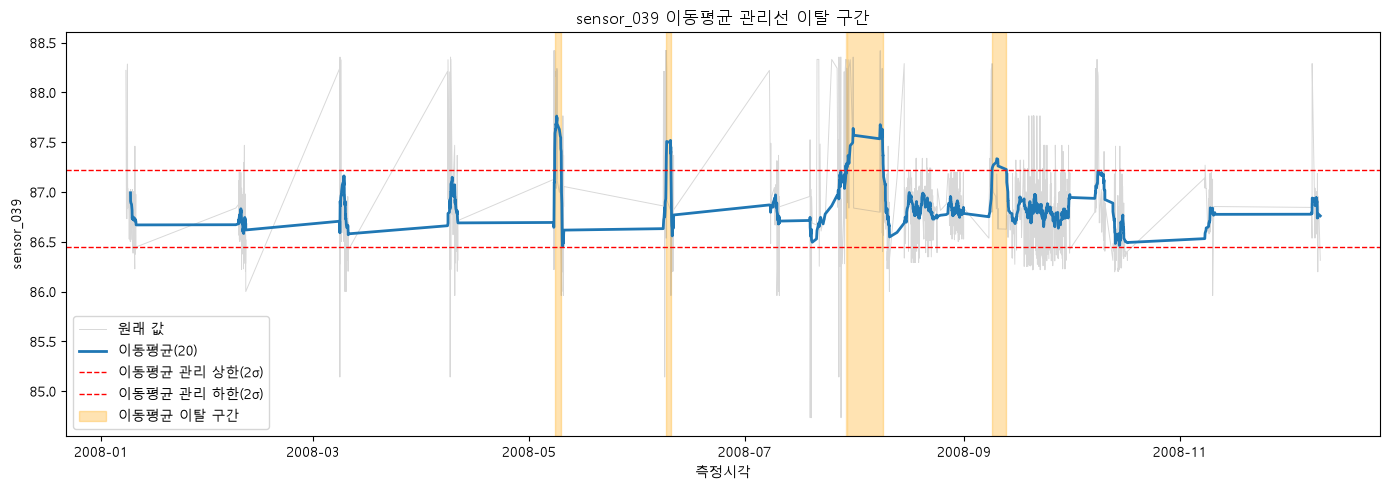

저장 완료: C:\Users\13sx0\Desktop\SECOM-PROJECT\day05\lab15_timeseries\results\sensor_trend_zones.png


In [11]:
import matplotlib.pyplot as plt
import os

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs('results', exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["측정시각"], df[센서], color='gray', alpha=0.3, linewidth=0.7, label='원래 값')
ax.plot(df["측정시각"], df["이동평균"], color='tab:blue', linewidth=2, label='이동평균(20)')

ax.axhline(이동평균_상한, color='red', linestyle='--', linewidth=1, label='이동평균 관리 상한(2σ)')
ax.axhline(이동평균_하한, color='red', linestyle='--', linewidth=1, label='이동평균 관리 하한(2σ)')

# 이탈 구간을 색으로 표시
for i, 행 in 구간표.iterrows():
    ax.axvspan(행['시작'], 행['끝'], color='orange', alpha=0.3,
               label='이동평균 이탈 구간' if i == 0 else None)

ax.set_xlabel('측정시각')
ax.set_ylabel(센서)
ax.set_title(f'{센서} 이동평균 관리선 이탈 구간')
ax.legend()
plt.tight_layout()

plt.savefig('results/sensor_trend_zones.png', dpi=150)
plt.show()

print('저장 완료:', os.path.abspath('results/sensor_trend_zones.png'))

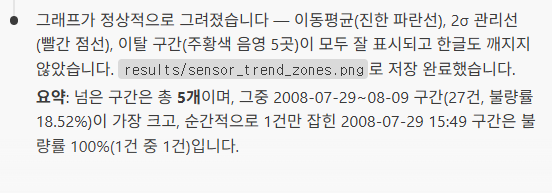

### 흐름이 선을 넘은 구간

| 구간 | 언제부터 언제까지 | 그 구간 건수 | 불량 | 불량률 |
|---|---|---|---|---|
| 1 | [5월 8일 ~ 5월 10일] | [21] | [2] | [9.52%] |
| 2 | [6월 8일 ~ 6월 10일] | [15] | [2] | [13.33%] |
| 3 | [7월 29일 한 줄] | [1] | [1] | [100.00%] |
| 4 | [7월 29일 ~ 8월 9일] | [27] | [5] | [18.52%] |
| 5 | [9월 8일 ~ 9월 13일] | [13] | [2] | [15.38%] |

- 알게 된 것 : [구간 안 77건의 불량률이 15.58%로 전체 6.64%의 두 배 넘는다. 4번 구간이 가장 길고 불량도 가장 많다]
- 이게 한 줄씩 보는 것과 다른 점 : [언제부터 언제까지인지 기간이 나온다. 그 날짜에 무슨 일이 있었는지 물어볼 수 있다]
- 못 믿을 줄 : [3번 구간은 1건짜리라 100%가 아무 뜻이 없다]